<a href="https://colab.research.google.com/github/sapiree-hub/Hello2/blob/main/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Ethan Sapire

*NEUR 265*

**April 30, 2026**

In [52]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

In [53]:
url1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'

fear_traces = np.loadtxt(url2, delimiter=',')
extinction_predictors = np.loadtxt(url1, delimiter=',')

url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'
shock_index = np.loadtxt(url3, delimiter=',').astype(int)
tone_index = np.loadtxt(url4, delimiter=',').astype(int)

In [54]:
# Split traces into conditioning and extinction
conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10458:, :]

In [55]:
# Print shapes

print("Conditioning shape:", conditioning_traces.shape)
print("Extinction shape:", extinction_traces.shape)

Conditioning shape: (10458, 63)
Extinction shape: (14210, 63)


In [56]:
# Create time arrays

time_conditioning = np.arange(conditioning_traces.shape[0]) / 15
time_extinction = np.arange(extinction_traces.shape[0]) / 15

Number of ROIs: 63


-Length of conditioning session (seconds): 697.2

-Length of conditioning session (minutes): 11.62


-Length of Extinction session(seconds): 947.27

-Length of Extinction session(minutes): 15.79

In [72]:
#there was an error that I didn't understand, so I had to ask chatgpt.
#Apparently there was a difference in the number of data so the time alignment was off, if I recall correctly.
#This was what I had to do in order to fix the issue


n = min(extinction_traces.shape[0], extinction_predictors.shape[0])

extinction_traces = extinction_traces[:n]

extinction_predictors = extinction_predictors[:n]

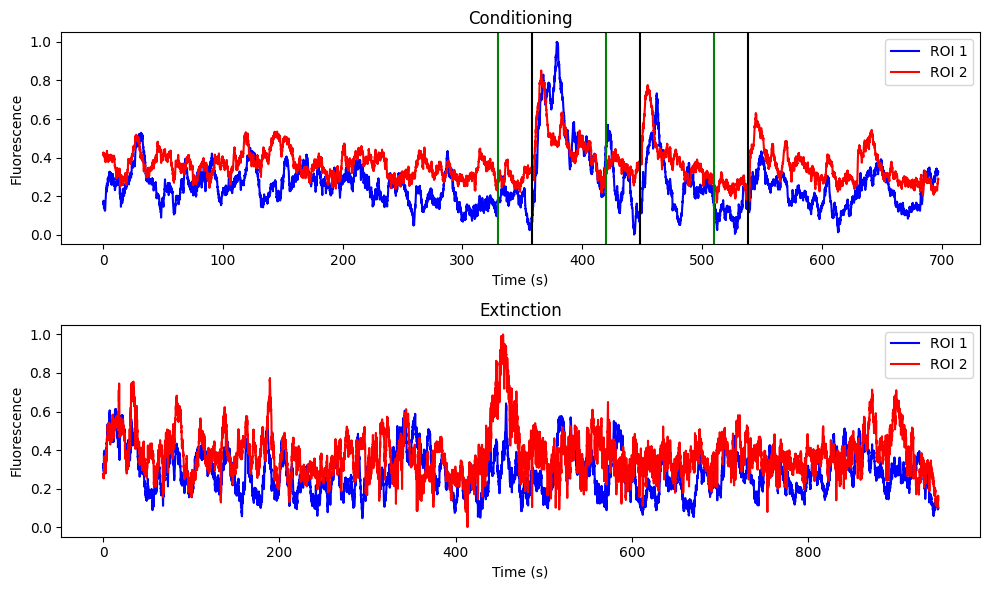

In [57]:
# Plot first two ROIs

fig, axs = plt.subplots(2, 1, figsize=(10,6))

# Conditioning plot

axs[0].plot(time_conditioning, conditioning_traces[:,0], color='blue', label='ROI 1')
axs[0].plot(time_conditioning, conditioning_traces[:,1], color='red', label='ROI 2')

# Shock lines (black)

for i in shock_index:

    axs[0].axvline(x=i, color='black')

# Tone lines (green)

for i in tone_index:

    axs[0].axvline(x=i, color='green')

axs[0].set_title('Conditioning')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Fluorescence')
axs[0].legend()

# Extinction plot

axs[1].plot(time_extinction, extinction_traces[:,0], color='blue', label='ROI 1')
axs[1].plot(time_extinction, extinction_traces[:,1], color='red', label='ROI 2')
axs[1].set_title('Extinction')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Fluorescence')
axs[1].legend()

plt.tight_layout()
plt.show()

ROI 1 shows stronger responses during conditioning compared to extinction, while ROI 2 shows [your observation].

There appears to be [some / little / no] consistency between how cells respond during conditioning and extinction.

In [70]:
# Create shock array
shock_array = np.zeros(10458)
for i in range(10458):
    if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
        shock_array[i] = 1
    elif i >= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
        shock_array[i] = 1
    elif i >= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
        shock_array[i] = 1

# Create tone array
tone_array = np.zeros(10458)
for i in range(10458):
    if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
        tone_array[i] = 1
    elif i >= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
        tone_array[i] = 1
    elif i >= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
        tone_array[i] = 1

# Combine predictors
from pandas import DataFrame as df
predictors_conditioning = df({
    'Intercept': np.ones_like(tone_array),
    'tone onset': tone_array,
    'shock onset': shock_array})

In [59]:
import statsmodels.api as sm

from statsmodels.genmod.families import Poisson

# Store 'r' values

num_rois = conditioning_traces.shape[1]
r_model_conditioning = np.zeros(num_rois)

for i in range(num_rois):

    trace = conditioning_traces[:, i]

    model = sm.GLM(trace, predictors_conditioning, family=Poisson())

    results = model.fit()
    predicted = results.predict()
    r = pearsonr(trace, predicted)

    r_model_conditioning[i] = r.statistic

In [67]:
# Store extinction 'r' values
num_rois_ext = extinction_traces.shape[1]
r_index_extinction = np.zeros(num_rois_ext)

for i in range(num_rois_ext):
    trace = extinction_traces[:, i]

    model = sm.GLM(trace, extinction_predictors, family=Poisson())
    results = model.fit()

    predicted = results.predict()

    r = pearsonr(trace, predicted)
    r_index_extinction[i] = r.statistic

In [68]:
# Correlate conditioning vs extinction 'r' values

r_final = pearsonr(r_model_conditioning, r_index_extinction)

print("Final correlation:", r_final)

Final correlation: PearsonRResult(statistic=np.float64(0.014779730798122465), pvalue=np.float64(0.9084708216602402))


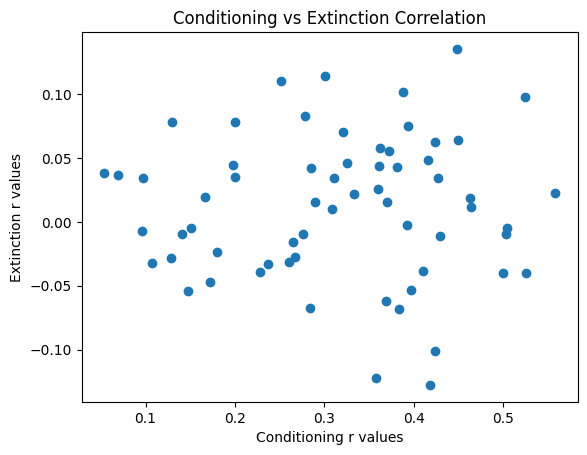

In [69]:
# Scatter plot of 'r' values

plt.scatter(r_model_conditioning, r_index_extinction)

plt.xlabel('Conditioning r values')

plt.ylabel('Extinction r values')

plt.title('Conditioning vs Extinction Correlation')

plt.show()